# 03 A first gradient, checked against TAF

- **Tier:** laptop (CPU only)
- **Run time:** about 14 min (measured: 835 s on a compute node pinned to 8 cores; two adjoint programs, one
  tangent program and eight cost evaluations, mostly compiling)
- **Peak memory:** about 5.5 GB (measured: 5.2 GiB)
- **Experiment:** `verification/1D_ocean_ice_column`, variant `input_ad` (one ocean column with sea ice, 23
  levels, 10 steps; the cost and the control `xx_theta` are those of `data.ctrl` / `data.grdchk`)
- **Shows:** the adjoint gradient with `exp.gradient`, the gradient check with `exp.grdchk` printed as
  `output_adm.txt` prints it, the comparison with TAF's numbers in `results/output_adm.txt`; then a dot test that
  goes below the API, into `mitjax/drivers/`.

There is no hand-written adjoint in mitjax: JAX differentiates the same code that runs forward. The gradient is
the derivative of the experiment's own cost function (`COST_FINAL`'s `fc`) with respect to its own control
variable, set up from `data.ctrl` as `pkg/ctrl` sets it up.

In [1]:
import os
os.environ.setdefault("JAX_PLATFORMS", "cpu")

import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

import mitjax
from mitjax import paths

VERIFICATION = paths.UPSTREAM / "verification"


def new_out(name):
    n = 1
    while Path(f"runs/{name}-{n}").exists():
        n += 1
    return Path(f"runs/{name}-{n}")


def digits(a, b):
    """Agreeing significant digits of two numbers: floor(-log10(|a-b| / max(|a|,|b|))), 16 when equal (testreport
    counts on the printed values and can differ by one)."""
    if a == b:
        return 16
    return int(np.floor(-np.log10(abs(a - b) / max(abs(a), abs(b)))))


ad = mitjax.load(VERIFICATION / "1D_ocean_ice_column", variant="input_ad")

## The gradient

`ad.gradient(out=...)` runs the model forward, evaluates the cost and returns `dfc/dxx` for the control named in
`data.grdchk` (here `xx_theta`, an initial-temperature control); it also writes the gradient to an `adxx_*` file
pair (`.data` / `.meta`) in the run directory.

324 s; control xx_theta, mode 'run'; fc = 6.919357199964371E+05
files: ['adxx_theta.0000000000.data', 'adxx_theta.0000000000.meta']


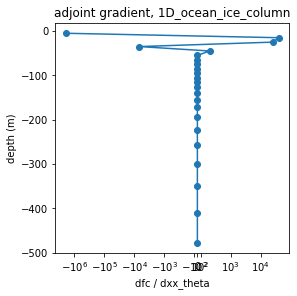

In [2]:
t0 = time.time()
g = ad.gradient(out=new_out("03_gradient"))
print(f"{time.time() - t0:.0f} s; control {g.control}, mode {g.mode!r}; fc = {g.fc:.15E}")
print("files:", [p.name for p in g.files])
adxx = g.adxx[1]                                   # record 1, storage layout [tile, k, j, i] with halos
sz = ad.config.cfg.size
col = adxx[0, :, sz.OLy, sz.OLx]                   # the one water column (i = j = 1)
assert np.isfinite(adxx).all(), "the gradient must be finite everywhere, also in halos and on land"

P = ad.config.params.values                        # the REAL namelist values, "file:group:name(index)"
name = "delr" if "data:parm04:delr(1)" in P else "delz"     # this experiment's data writes delZ (PARM04)
delR = np.array([float(P[f"data:parm04:{name}({k})"]) for k in range(1, sz.Nr + 1)])
z = -(np.cumsum(delR) - 0.5 * delR)                # depth of the cell centres (m)
fig, ax = plt.subplots(figsize=(4, 4), dpi=72, constrained_layout=True)
ax.plot(col, z, "o-")
ax.set_xscale("symlog", linthresh=1e3)            # the surface value dominates
ax.set_xlabel("dfc / dxx_theta"); ax.set_ylabel("depth (m)")
ax.set_title("adjoint gradient, 1D_ocean_ice_column")
plt.show()

## The gradient check

`ad.grdchk(out=...)` is `pkg/grdchk`'s `GRDCHK_MAIN`: at the points `data.grdchk` names it computes the cost with
the control perturbed by `+grdchk_eps` and `-grdchk_eps`, the centred finite difference, and the adjoint gradient
at that point, and prints them as `output_adm.txt` does:

In [3]:
t0 = time.time()
chk = ad.grdchk(out=new_out("03_grdchk"))
print(f"{time.time() - t0:.0f} s")
start = next(n for n, ln in enumerate(chk.lines) if "Gradient check results" in ln)
print("\n".join(chk.lines[start - 1:]))

374 s
(PID.TID 0000.0001) // =======================================================
(PID.TID 0000.0001) // Gradient check results  >>> START <<<
(PID.TID 0000.0001) // =======================================================
(PID.TID 0000.0001) 
(PID.TID 0000.0001)  EPS = 1.000000E-07 ; grdchk CTRL var/file name: "xx_theta"
(PID.TID 0000.0001) 
(PID.TID 0000.0001) grdchk output h.p:  Id Itile Jtile LAYER   bi   bj   X(Id)           X(Id)+/-EPS
(PID.TID 0000.0001) grdchk output h.c:  Id  FC                   FC1                  FC2
(PID.TID 0000.0001) grdchk output h.g:  Id     FC1-FC2/(2*EPS)      ADJ GRAD(FC)         1-FDGRD/ADGRD
(PID.TID 0000.0001) 
(PID.TID 0000.0001) grdchk output (p):   1     1     1     1    1    1   0.000000000E+00 -1.000000000E-07
(PID.TID 0000.0001) grdchk output (c):   1  6.9193571999644E+05  6.9193553086898E+05  6.9193590912411E+05
(PID.TID 0000.0001) grdchk output (g):   1    -1.8912756338250E+06 -1.8912763605492E+06  3.8425068504822E-07
(PID.TID 0000.000

TAF's run of the same experiment, from `results/output_adm.txt`:

In [4]:
taf_lines = ad.results().output_adm.read_text().splitlines()
start = next(n for n, ln in enumerate(taf_lines) if "Gradient check results  >>> START" in ln)
stop = next(n for n, ln in enumerate(taf_lines) if "Gradient check results  >>> END" in ln)
print("\n".join(taf_lines[start - 1:stop + 2]))

(PID.TID 0000.0001) // =======================================================
(PID.TID 0000.0001) // Gradient check results  >>> START <<<
(PID.TID 0000.0001) // =======================================================
(PID.TID 0000.0001) 
(PID.TID 0000.0001)  EPS = 1.000000E-07 ; grdchk CTRL var/file name: "xx_theta"
(PID.TID 0000.0001) 
(PID.TID 0000.0001) grdchk output h.p:  Id Itile Jtile LAYER   bi   bj   X(Id)           X(Id)+/-EPS
(PID.TID 0000.0001) grdchk output h.c:  Id  FC                   FC1                  FC2
(PID.TID 0000.0001) grdchk output h.g:  Id     FC1-FC2/(2*EPS)      ADJ GRAD(FC)         1-FDGRD/ADGRD
(PID.TID 0000.0001) 
(PID.TID 0000.0001) grdchk output (p):   1     1     1     1    1    1   0.000000000E+00 -1.000000000E-07
(PID.TID 0000.0001) grdchk output (c):   1  6.9193571999644E+05  6.9193553086898E+05  6.9193590912411E+05
(PID.TID 0000.0001) grdchk output (g):   1    -1.8912756338250E+06 -1.8912763605492E+06  3.8425067871994E-07
(PID.TID 0000.0001) 
(P

Point by point: the adjoint gradient of mitjax against TAF's adjoint gradient, and each against its own finite
difference. The finite difference has its own error (truncation and round-off of `grdchk_eps = 1e-7`), so the
adjoint-to-adjoint comparison is the sharp one. `mitjax.compare` applies testreport's adjoint check list
(`admGrd` decides; 10 digits pass).

In [5]:
def g_lines(lines):
    return [ln.split("(g):")[1].split() for ln in lines if "grdchk output (g):" in ln]


ours, taf = g_lines(chk.lines), g_lines(taf_lines)
print(" Id   adjoint (mitjax)        adjoint (TAF)           digits   FD/adjoint-1 (mitjax)")
agree = []
for a, b in zip(ours, taf):
    d = digits(float(a[2]), float(b[2]))
    agree.append(d)
    print(f"{a[0]:>3s}  {float(a[2]):22.14E}  {float(b[2]):22.14E}  {d:5d}   {-float(a[3]):.2E}")
rep = mitjax.compare(chk, ad.results())
print(rep.summary)

 Id   adjoint (mitjax)        adjoint (TAF)           digits   FD/adjoint-1 (mitjax)
  1   -1.89127636054920E+06   -1.89127636054920E+06     16   -3.84E-07
  2    4.00010117985990E+04    4.00010117986030E+04     12   -1.78E-05
  3    2.59864733519040E+04    2.59864733519040E+04     16   -2.49E-06
  4   -6.71549955419980E+03   -6.71549955420080E+03     12   4.66E-05
Y Y Y Y 16>13<16 -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- pass  1D_ocean_ice_column


In [6]:
MIN_GRAD_DIGITS = 10                               # testreport's MATCH_CRIT on admGrd
assert len(ours) == len(taf) == 4
assert min(agree) >= MIN_GRAD_DIGITS, agree
assert rep.verdict == "pass", rep.summary
assert all(abs(float(a[3])) < 1e-3 for a in ours), "the finite differences confirm the adjoint"

## A dot test, below the API

The API stops at gradients and gradient checks. Anything else goes one level down, to the drivers the API wraps
(`mitjax/drivers/`); this part of the notebook uses them directly, so it depends on interfaces that are less
stable than the API's.

The dot test checks that the adjoint is the transpose of the tangent linear model: for a random direction `v`,
the tangent linear model gives `dfc = J v` (`jax.jvp`), the adjoint gives the gradient `g = J^T 1`, and the two
must agree: `J v = g . v` to round-off. `GenarrAdjoint` is the driver for a control of `xx_genarr3d` type
(`CTRL_MAP_INI_GENARR`); it holds the jitted cost, gradient and tangent programs. We take the gradient `g` from
`ad.gradient` above (it ran the same driver) and compile only the tangent program here.

In [7]:
import jax.numpy as jnp

from mitjax.drivers import adjoint_run
from mitjax.drivers.grdchk import control_by_name

m = ad.model(new_out("03_dottest"))                # the drivers' Model in a new run directory
ctl = control_by_name(m, "xx_theta")
drv = adjoint_run.GenarrAdjoint(m, key=ctl.key)
grad = g.adxx[1]                                   # the adjoint gradient computed above (same layout as the control)
v = jnp.asarray(np.random.default_rng(1).standard_normal(np.shape(drv.theta0)))
fc_t, tangent = drv.jvp(v)                         # the tangent-linear model in direction v
adjoint = float(jnp.vdot(grad, v))
rel = abs(float(tangent) - adjoint) / abs(adjoint)
print(f"fc (adjoint program) = {g.fc:.15E}\nfc (tangent program) = {float(fc_t):.15E}")
print(f"J v (tangent) = {float(tangent):.15E}\ng . v (adjoint) = {adjoint:.15E}\nrelative difference {rel:.1E}")

fc (adjoint program) = 6.919357199964371E+05
fc (tangent program) = 6.919357199964371E+05
J v (tangent) = 1.301327166664137E+06
g . v (adjoint) = 1.301327166664079E+06
relative difference 4.5E-14


In [8]:
assert np.isfinite(float(tangent)) and np.isfinite(adjoint)
assert rel < 1e-10, rel                             # transposes of each other to round-off

## `mode="run"` and `mode="exact"`

TAF's adjoint of a verification experiment is often not the exact derivative of its forward model: switches in
`data.autodiff` (for example `useApproxAdvectionInAdMode`, `SEAICEuseFREEDRIFTswitchInAd`) and options such as
`cg2dFullAdjoint = .FALSE.` change what the adjoint computes, not the forward run. `gradient(mode="run")`, the
default, applies the run's own switches as backward-only changes, so that the gradient is comparable with TAF's
`output_adm.txt`; `mode="exact"` applies none and gives the exact derivative of the forward model. Here
`data.autodiff` sets no such switch and the free surface is linear (no control reaches the CG2D operator), so the
two modes compute the same gradient (`mitjax/ad/modes.py`, `mitjax/drivers/ad_switches.py`). Notebook 06 (cluster
tier) shows `global_ocean.cs32x15`, where they differ.